<a href="https://colab.research.google.com/github/H-levison/linear_regression_model/blob/main/summative/linear_regression/multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Bitcoin Price Prediction Model
In this notebook, I am evaluating machine learning models to predict the closing price of Bitcoin.

**Mathematical Foundation (Baseline Linear Regression):**
$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + ... + \beta_n X_n + \epsilon$

**Objective:**
Instead of using trivial metrics like the daily `open`, `high`, or `low` (which would cause data leakage), I will predict the `close` price based on macroeconomic indicators and sentiment data: S&P 500, Gold, US Dollar Index (DXY), Fear & Greed Index, Hash Rate, and Google Trends.

In [17]:
# Importing essential libraries for data manipulation, visualization, modeling, and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Setting a random seed for reproducible results
np.random.seed(42)

In [18]:
# 1. Load the dataset
df = pd.read_csv('Bitcoin Market Analysis Dataset (2021-2025).csv')

# Convert the 'date' column to datetime and set it as the index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("Original Dataset Shape:", df.shape)
display(df.head())

Original Dataset Shape: (1826, 21)


,adj close,close,high,low,open,volume,sp500_close,gold_close,dxy_close,fng_score,...,google_trends_score,btc_return,btc_log_return,sp500_return,gold_return,dxy_return,btc_vol_7d,btc_vol_14d,target_return,target_direction
date,,,,,,,,,,,,,,,,,,,,,
2021-01-11,35566.656250,35566.656250,38346.531250,30549.599609,38346.531250,123320567399,3799.610107,1849.599976,90.540001,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.089979,0
2021-01-12,33922.960938,33922.960938,36568.527344,32697.976562,35516.359375,74773277909,3801.189941,1842.900024,90.050003,84.0,...,NaN,-0.046215,-0.047316,0.000416,-0.003622,-0.005412,NaN,NaN,-0.039888,0
2021-01-13,37316.359375,37316.359375,37599.960938,32584.667969,33915.121094,69364315979,3809.840088,1853.599976,90.320000,78.0,...,NaN,0.100032,0.095340,0.002276,0.005806,0.002998,NaN,NaN,-0.184472,0
2021-01-14,39187.328125,39187.328125,39966.406250,36868.562500,37325.109375,63615990033,3795.540039,1850.300049,90.239998,83.0,...,NaN,0.050138,0.048922,-0.003753,-0.001780,-0.000886,NaN,NaN,-0.145997,0
2021-01-15,36825.367188,36825.367188,39577.710938,34659.589844,39156.707031,67760757881,3768.250000,1829.300049,90.779999,88.0,...,NaN,-0.060274,-0.062166,-0.007190,-0.011350,0.005984,NaN,NaN,-0.068132,0


In [19]:
# 2. Data Cleaning & Feature Engineering

# DROPPING COLUMNS:
# Dropping price-derivative columns (open, high, low, adj close) to prevent severe data leakage.
# Also dropping future-looking columns like 'target_return' and 'target_direction'.
columns_to_drop = [
    'adj close', 'open', 'high', 'low',
    'btc_return', 'btc_log_return', 'sp500_return',
    'gold_return', 'dxy_return', 'btc_vol_7d',
    'btc_vol_14d', 'target_return', 'target_direction'
]

clean_df = df.drop(columns=columns_to_drop)

# HANDLING MISSING VALUES:
# Using 'forward fill' (ffill) for time-series data to propagate the last known value forward.
# Dropping any remaining NaNs at the very start.
clean_df = clean_df.ffill().dropna()

print("Cleaned Dataset Shape:", clean_df.shape)

Cleaned Dataset Shape: (1820, 8)


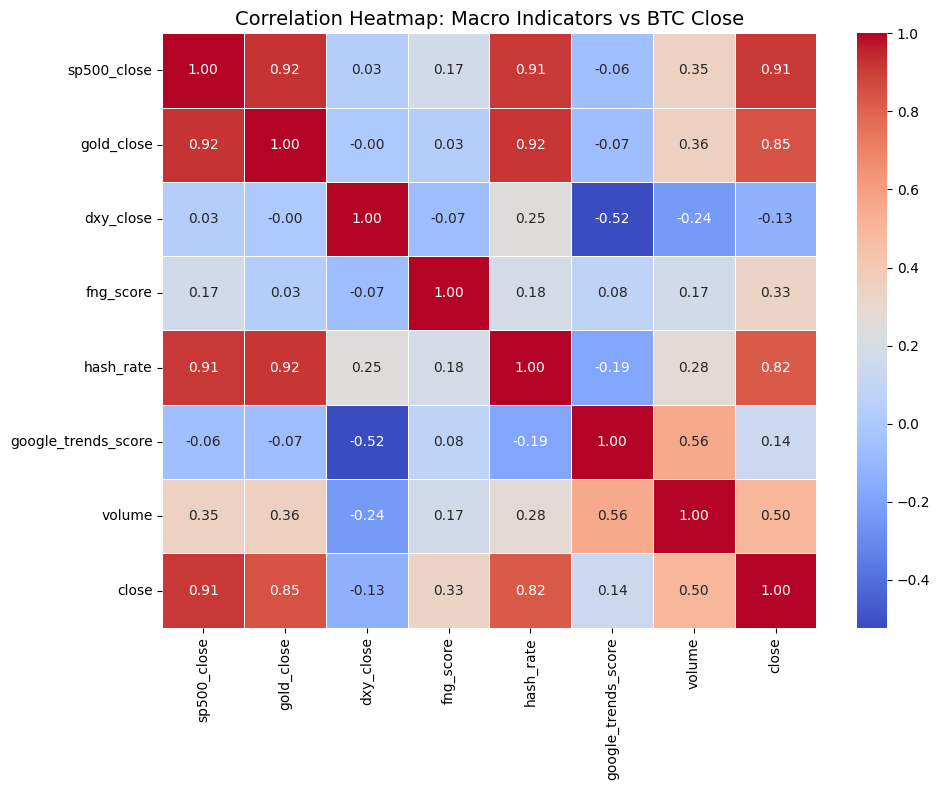

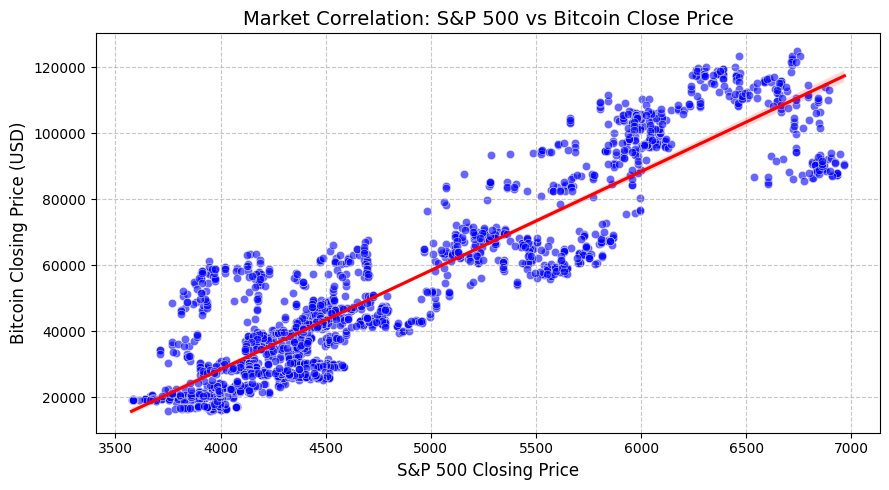

In [25]:
# 3. Exploratory Data Analysis & Visualizations

# Defining features and target for our visualizations and upcoming models
features = ['sp500_close', 'gold_close', 'dxy_close', 'fng_score', 'hash_rate', 'google_trends_score', 'volume']
target = 'close'

# --- VISUALIZATION 1: Correlation Heatmap ---
# Impact on training: Helps identify multicollinearity and shows which features
# have the strongest linear relationship with the target ('close').
plt.figure(figsize=(10, 8))
correlation_matrix = clean_df[features + [target]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap: Macro Indicators vs BTC Close', fontsize=14)
plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: Scatterplot (Variables Distribution) ---
# Impact on training: Verifies if a linear relationship exists. If the relationship
# is highly non-linear, a Linear Regression model will perform poorly, justifying a Decision Tree.
plt.figure(figsize=(9, 5))
sns.scatterplot(data=clean_df, x='sp500_close', y='close', alpha=0.6, color='blue')
sns.regplot(data=clean_df, x='sp500_close', y='close', scatter=False, color='red')
plt.title('Market Correlation: S&P 500 vs Bitcoin Close Price', fontsize=14)
plt.xlabel('S&P 500 Closing Price', fontsize=12)
plt.ylabel('Bitcoin Closing Price (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
# 4. Feature Selection & Splitting the Data
X = clean_df[features]
y = clean_df[target]

# Splitting 80% for training and 20% for testing.
# We use shuffle=True (a random split) here to expose both sets to various market cycles,
# allowing complex models to capture the volatility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1456, 7)
Testing data shape: (364, 7)


In [22]:
# 5. Training Multiple Models to Find the Best Fit

# --- Model 1: Multivariate Linear Regression (Baseline) ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# --- Model 2: Decision Tree Regressor (The Challenger) ---
# Decision Trees can model non-linear relationships, which is perfect for crypto volatility
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("--- Head-to-Head Model Performance ---")
print(f"Linear Regression -> RMSE: ${lr_rmse:.2f} | R2 Score: {lr_r2:.4f}")
print(f"Decision Tree     -> RMSE: ${dt_rmse:.2f} | R2 Score: {dt_r2:.4f}")

--- Head-to-Head Model Performance ---
Linear Regression -> RMSE: $8888.55 | R2 Score: 0.9082
Decision Tree     -> RMSE: $3591.06 | R2 Score: 0.9850


In [23]:
# 6. Saving the Winning Model
# The Decision Tree significantly outperformed the baseline linear model,
# so we will export the Decision Tree for production in our API.

winning_model_filename = 'bitcoin_decision_tree_model.pkl'
joblib.dump(dt_model, winning_model_filename)

print(f"Success! The superior Decision Tree model has been saved as '{winning_model_filename}'")

Success! The superior Decision Tree model has been saved as 'bitcoin_decision_tree_model.pkl'
